In [1]:
import numpy as np
import os
from glob import glob
from util.plotting import plot_3d_array_interactive
from RGTnet.models.net3d import model
from RGTnet.utils import get_parameter_number
from DNN.lw_spacenet import UNet3D, count_parameters
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

%matplotlib inline

In [5]:
model = UNet3D(in_channels=1, out_channels=1, init_features=16)
print(count_parameters(model))

6562158


In [123]:
ind = 168
sl = (96, slice(None), slice(None))
sl2 = (1, slice(None), slice(None))
rgt_init = sorted(glob("/mnt/storage/nnseismic/synthetic_data/train/rgt/*"), key=lambda x: int(os.path.basename(x).split('.')[0]))
seis = sorted(glob("/mnt/storage/nnseismic/synthetic_data/train/seis/*"), key=lambda x: int(os.path.basename(x).split('.')[0]))
rgt = np.fromfile(rgt_init[ind], dtype=np.float32)
rgt = rgt.reshape((128, 128, 128))
seis_s = np.fromfile(seis[ind], dtype=np.float32)
seis_s = seis_s.reshape((128, 128, 128))

In [124]:
print(seis[ind])

/mnt/storage/nnseismic/synthetic_data/train/seis/00195.dat


Text(0.5, 1.0, 'Relative Geologic Time (RGT)')

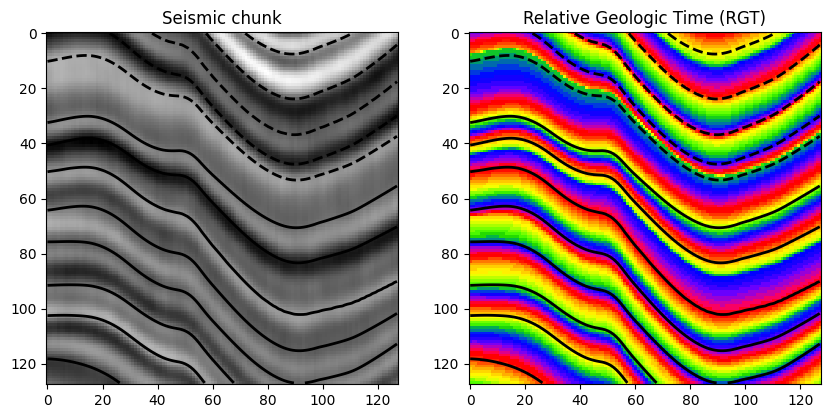

In [125]:
fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].imshow(seis_s[sl].T, cmap='grey', interpolation='nearest')
axs[0].contour(rgt[sl].T,np.linspace(np.min(rgt),np.max(rgt),20),colors='black',linewidths=2)
axs[0].set_title('Seismic chunk')

axs[1].imshow(rgt[sl].T, cmap='prism', interpolation='nearest')
axs[1].contour(rgt[sl].T,np.linspace(np.min(rgt),np.max(rgt),20),colors='black',linewidths=2)
axs[1].set_title('Relative Geologic Time (RGT)')

Text(0.5, 1.0, 'Relative Geologic Time (RGT)')

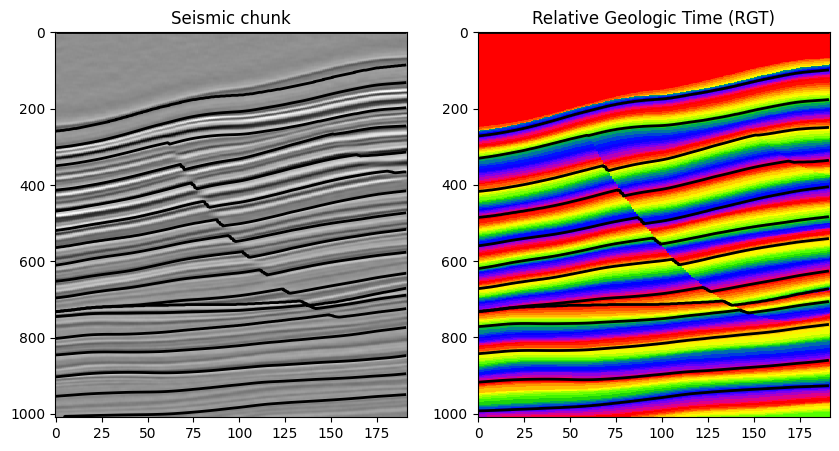

In [62]:
sf = "/mnt/storage/nnseismic/synthetic_data/raw/labeled/seismicCubes_cumsum_fullstack_2026.27340332.npy"
seis = np.load(sf)
tf = "/mnt/storage/nnseismic/synthetic_data/raw/labeled/faulted_age_2026.27340332.npy"
rgt = np.load(tf)

fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].imshow(seis[sl].T, cmap='grey', interpolation='nearest', aspect='auto')
axs[0].contour(rgt[sl].T,np.linspace(np.min(rgt),np.max(rgt),20),colors='black',linewidths=2)
axs[0].set_title('Seismic chunk')

axs[1].imshow(rgt[sl].T, cmap='prism', interpolation='nearest', aspect='auto')
axs[1].contour(rgt[sl].T,np.linspace(np.min(rgt),np.max(rgt),15),colors='black',linewidths=2)
axs[1].set_title('Relative Geologic Time (RGT)')

/tmp/ipykernel_20137/1615692619.py:16: UserWarning: The following kwargs were not used by contour: 'label'
  cp = axs[0].contour(rgt[sl].T,np.linspace(np.min(rgt),np.max(rgt),15),colors='black',linewidths=2, label='pred')
/tmp/ipykernel_20137/1615692619.py:17: UserWarning: The following kwargs were not used by contour: 'label'
  cr = axs[0].contour(rgt_targ[sl].T,np.linspace(np.min(rgt_targ),np.max(rgt_targ),15),colors='purple',linewidths=2, label='real')


Text(0.5, 1.0, 'Relative Geologic Time real (RGT)')

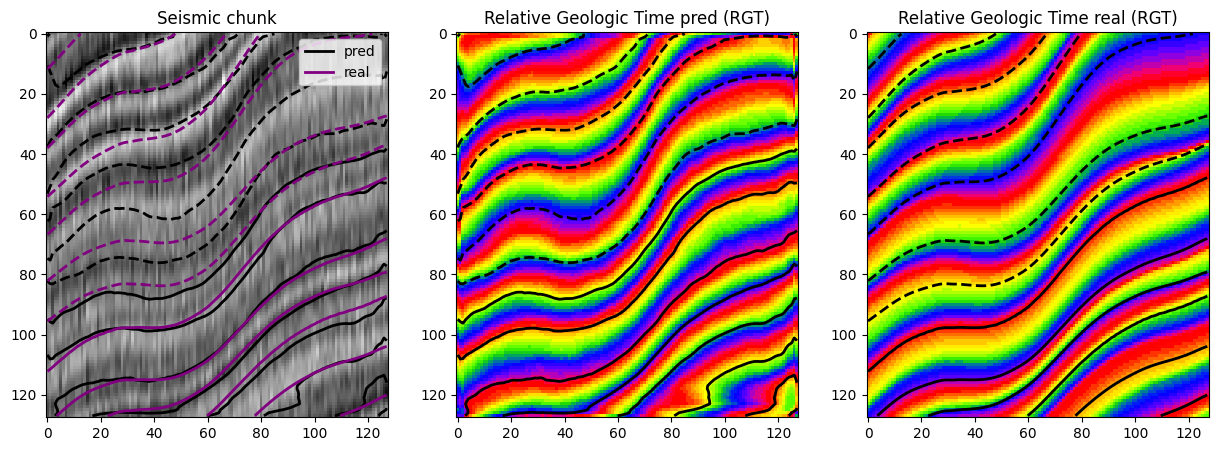

In [43]:
#idx = 8, 9, 15, 20
ind = 20
sl = (96, slice(None), slice(None))
rgt_file = sorted(glob("/mnt/storage/nnseismic/runs/exp3_Train/Apr13_152153_Test/bin/pred/*"), key=lambda x: int(os.path.basename(x).split('.')[0].strip('pred_rgt')))
seis_file = sorted(glob("/mnt/storage/nnseismic/synthetic_data/val/seis/*"), key=lambda x: int(os.path.basename(x).split('.')[0]))
rgt_file_targ = sorted(glob("/mnt/storage/nnseismic/synthetic_data/val/rgt/*"), key=lambda x: int(os.path.basename(x).split('.')[0]))
rgt = np.fromfile(rgt_file[ind], dtype=np.float32)
rgt = rgt.reshape((128, 128, 128))
seis = np.fromfile(seis_file[ind], dtype=np.float32)
seis = seis.reshape((128, 128, 128))
rgt_targ = np.fromfile(rgt_file_targ[ind], dtype=np.float32)
rgt_targ = rgt_targ.reshape((128, 128, 128))

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].imshow(seis[sl].T, cmap='grey', interpolation='nearest', aspect='auto')
cp = axs[0].contour(rgt[sl].T,np.linspace(np.min(rgt),np.max(rgt),15),colors='black',linewidths=2, label='pred')
cr = axs[0].contour(rgt_targ[sl].T,np.linspace(np.min(rgt_targ),np.max(rgt_targ),15),colors='purple',linewidths=2, label='real')
axs[0].set_title('Seismic chunk')
axs[0].legend([Line2D([0], [0], color='black', lw=2), Line2D([0], [0], color='purple', lw=2)], 
              ['pred', 'real'])

axs[1].imshow(rgt[sl].T, cmap='prism', interpolation='nearest', aspect='auto')
axs[1].contour(rgt[sl].T,np.linspace(np.min(rgt),np.max(rgt),15),colors='black',linewidths=2)
axs[1].set_title('Relative Geologic Time pred (RGT)')

axs[2].imshow(rgt_targ[sl].T, cmap='prism', interpolation='nearest', aspect='auto')
axs[2].contour(rgt_targ[sl].T,np.linspace(np.min(rgt_targ),np.max(rgt_targ),15),colors='black',linewidths=2)
axs[2].set_title('Relative Geologic Time real (RGT)')

In [6]:
from util.metrics import *
rgt_file = sorted(glob("/mnt/storage/nnseismic/runs/snet-6-nosmooth/infer/*"), key=lambda x: int(os.path.basename(x).split('.')[0].strip('pred_rgt')))
rgt_file_targ = sorted(glob("/mnt/storage/nnseismic/synthetic_data/val/rgt/*"), key=lambda x: int(os.path.basename(x).split('.')[0]))
pred_mae = []
pred_rmse = []
pred_mrpd = []
for ind in range(len(rgt_file)):
    rgt = np.fromfile(rgt_file[ind], dtype=np.float32)
    rgt = rgt.reshape((128, 128, 128))
    rgt_targ = np.fromfile(rgt_file_targ[ind], dtype=np.float32)
    rgt_targ = rgt_targ.reshape((128, 128, 128))
    pred_mae.append(mae(rgt, rgt_targ))
    pred_rmse.append(rmse(rgt, rgt_targ))
    pred_mrpd.append(mrpd(rgt, rgt_targ))

print(f"MAE: {np.mean(pred_mae)}\nRMSE: {np.mean(pred_rmse)}\nMRPD: {np.mean(pred_mae)}")

MAE: 0.11491910368204117
RMSE: 0.15158826112747192
MRPD: 0.11491910368204117


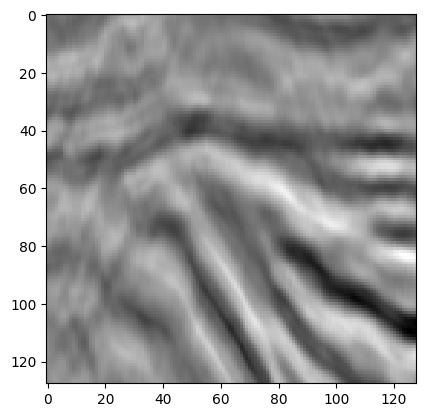

In [14]:
ind = 3
sl = (96, slice(None), slice(None))
# rgt_file = sorted(glob("/mnt/storage/nnseismic/runs/exp3_Train/Apr13_152153_Test/bin/pred/*"), key=lambda x: int(os.path.basename(x).split('.')[0].strip('pred_rgt')))
seis_file = sorted(glob("/mnt/storage/nnseismic/real_data/*.dat"), key=lambda x: int(os.path.basename(x).split('.')[0].lstrip('chunk_')))
# rgt = np.fromfile(rgt_file[ind], dtype=np.float32)
# rgt = rgt.reshape((128, 128, 128))
seis = np.fromfile(seis_file[ind], dtype=np.float32)
seis = seis.reshape((128, 128, 128))

# fig, axs = plt.subplots(1, 2, figsize=(15,5))
# axs[0].imshow(seis[sl].T, cmap='grey', interpolation='nearest', aspect='auto')
# cp = axs[0].contour(rgt[sl].T,np.linspace(np.min(rgt),np.max(rgt),15),colors='black',linewidths=2, label='pred')
# cr = axs[0].contour(rgt_targ[sl].T,np.linspace(np.min(rgt_targ),np.max(rgt_targ),15),colors='purple',linewidths=2, label='real')
# axs[0].set_title('Seismic chunk')
# axs[0].legend([Line2D([0], [0], color='black', lw=2), Line2D([0], [0], color='purple', lw=2)], 
#               ['pred', 'real'])

# axs[1].imshow(rgt[sl].T, cmap='prism', interpolation='nearest', aspect='auto')
# axs[1].contour(rgt[sl].T,np.linspace(np.min(rgt),np.max(rgt),15),colors='black',linewidths=2)
# axs[1].set_title('Relative Geologic Time pred (RGT)')
plt.imshow(seis[sl].T, cmap='grey', interpolation='nearest', aspect='equal' )

In [ ]:
cube = "/mnt/storage/nnseismic/synthetic_data/raw/labeled/seismicCubes_cumsum_fullstack_2026.27340332.npy"
testarr = np.load(cube)
plot_3d_array_interactive(testarr, axis='x', cmap='grey')

interactive(children=(IntSlider(value=0, description='X-index:', max=191), Output()), _dom_classes=('widget-in…

In [67]:


# print(seismic.size/1024/1024)
plot_3d_array_interactive(rgt, axis='x', cmap='jet')

interactive(children=(IntSlider(value=0, description='X-index:', max=127), Output()), _dom_classes=('widget-in…

In [ ]:

# print(seismic.size/1024/1024)
plot_3d_array_interactive(seis_s, axis='x', cmap='grey')

interactive(children=(IntSlider(value=0, description='X-index:', max=127), Output()), _dom_classes=('widget-in…

In [105]:
import pandas as pd
test = pd.read_csv("/mnt/storage/nnseismic/runs/exp2_Train/history/test_history.txt", sep=' |\t')
train = pd.read_csv("/mnt/storage/nnseismic/runs/exp2_Train/history/train_history.txt", sep=' |\t')

/tmp/ipykernel_32622/787564231.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  test = pd.read_csv("/mnt/storage/nnseismic/runs/exp2_Train/history/test_history.txt", sep=' |\t')
/tmp/ipykernel_32622/787564231.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  train = pd.read_csv("/mnt/storage/nnseismic/runs/exp2_Train/history/train_history.txt", sep=' |\t')


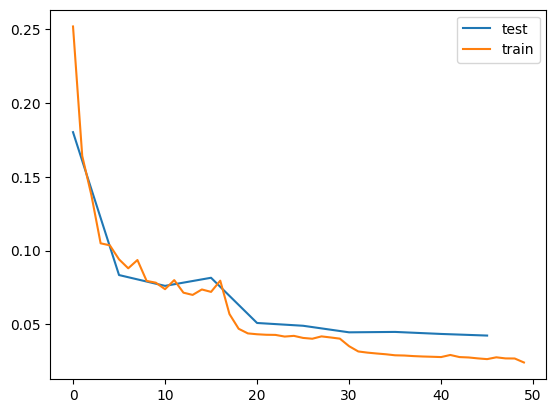

In [111]:
plt.plot(test.EPOCH, test.SSIM, label='test')
plt.plot(train.EPOCH, train.SSIM, label='train')
plt.legend()

In [16]:
seismic = np.fromfile("../data/0.dat", dtype=np.float32)
seismic = seismic.reshape((256, 256, 128))
plot_3d_array_interactive(seismic, axis='x', cmap='grey')

interactive(children=(IntSlider(value=0, description='X-index:', max=255), Output()), _dom_classes=('widget-in…

In [2]:
files = glob("../data/synthetic_data/run/seismic__2026.24239099_tagilst_test_5/*.npy")
for i in range(len(files)):
    print(f'{i} - {files[i]}')

In [3]:
cube = "../data/synthetic_data/run/seismic__2026.25220596_tagilsk_128_128_2000/faulted_age_2026.25220596.npy"
testarr = np.load(cube)
plot_3d_array_interactive(testarr, axis='x', cmap='prism')

interactive(children=(IntSlider(value=0, description='X-index:', max=127), Output()), _dom_classes=('widget-in…

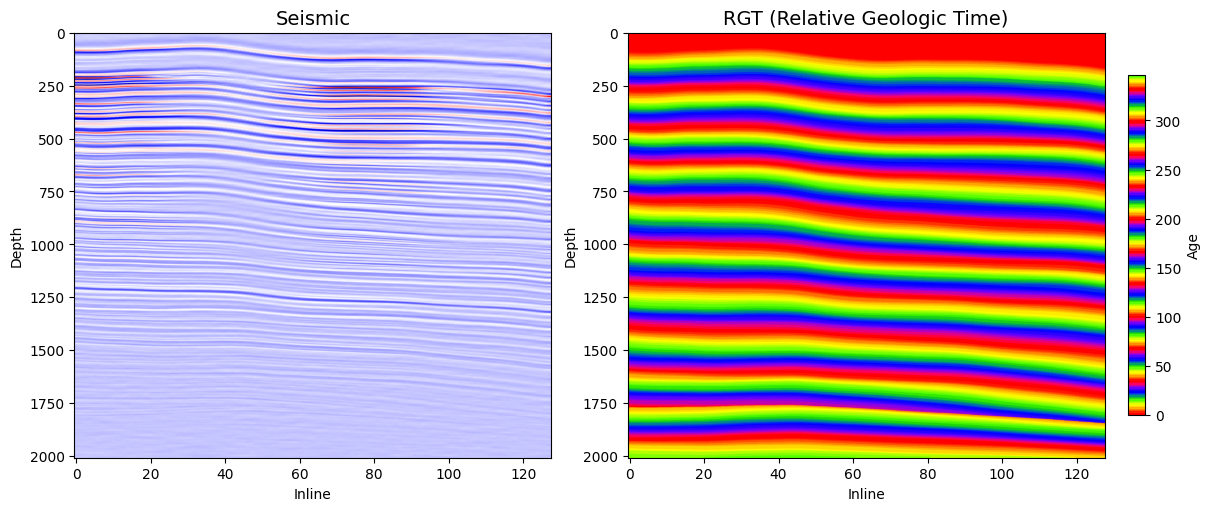

In [8]:
seismic_path = "../data/synthetic_data/run/seismic__2026.25220596_tagilsk_128_128_2000/seismicCubes_cumsum_fullstack_2026.25220596.npy"
rgt_path = "../data/synthetic_data/run/seismic__2026.25220596_tagilsk_128_128_2000/faulted_age_2026.25220596.npy"

seismic = np.load(seismic_path)
rgt = np.load(rgt_path)

slice_idx = 40

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Seismic plot
axes[0].imshow(seismic[slice_idx, :, :].T, cmap='seismic', aspect='auto')
axes[0].set_title('Seismic', fontsize=14)
axes[0].set_xlabel('Inline')
axes[0].set_ylabel('Depth')

# RGT plot
im = axes[1].imshow(rgt[slice_idx, :, :].T, cmap='prism', aspect='auto')
axes[1].set_title('RGT (Relative Geologic Time)', fontsize=14)
axes[1].set_xlabel('Inline')
axes[1].set_ylabel('Depth')

fig.colorbar(im, ax=axes[1], shrink=0.8, label='Age')

plt.show()

In [5]:
cube = "../data/synthetic_data/run/seismic__2026.24319790_tagilsk_2/qc_volume_rho_2026.24319790.npy"
testarr = np.load(cube)
plot_3d_array_interactive(testarr, axis='x')

interactive(children=(IntSlider(value=0, description='X-index:', max=99), Output()), _dom_classes=('widget-int…